In [1]:
# Cell 1: Import libraries, load and clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df_clean = df.copy()
df_clean = df_clean.drop(columns=['customerID'])
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Final shape:", df_clean.shape)

Final shape: (7043, 31)


In [2]:
# Cell 2: Split data and train baseline model
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
print("Baseline Random Forest accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Random Forest F1-score:", f1_score(y_test, y_pred_baseline))

Baseline Random Forest accuracy: 0.7863733144073811
Baseline Random Forest F1-score: 0.5500747384155455


In [3]:
# Cell 3: Tune hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']  # helps with our class imbalance
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1-score:", grid_search.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validated F1-score: 0.6437521918109497


In [4]:
# Cell 4: Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned)
recall = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

# Also run 5-fold cross-validation for a robustness check
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')
print(f"\n5-fold CV F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Accuracy:  0.7665
Precision: 0.5440
Recall:    0.7433
F1-score:  0.6282

Confusion Matrix:
[[802 233]
 [ 96 278]]

5-fold CV F1 scores: [0.66066066 0.66666667 0.64317181 0.63785395 0.61040788]
Mean CV F1: 0.6438 (+/- 0.0198)


                                 Feature  Importance
1                                 tenure    0.168711
3                           TotalCharges    0.143896
2                         MonthlyCharges    0.110688
25                     Contract_Two year    0.103706
10           InternetService_Fiber optic    0.066290
28        PaymentMethod_Electronic check    0.050693
24                     Contract_One year    0.040775
13                    OnlineSecurity_Yes    0.037538
19                       TechSupport_Yes    0.024848
16  DeviceProtection_No internet service    0.018326


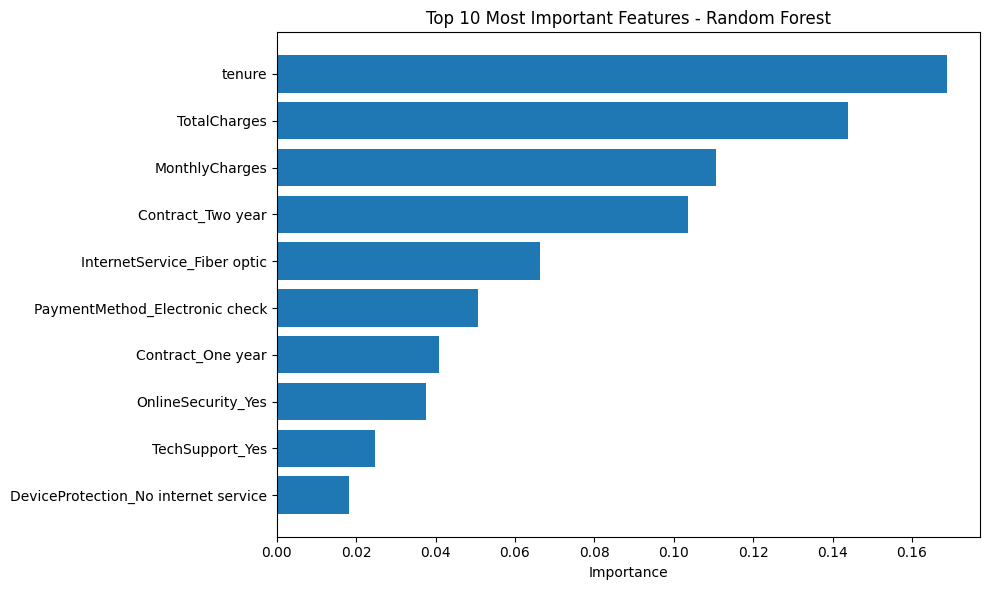

In [5]:
# Cell 5: Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features - Random Forest')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Summary
print("="*50)
print("TASK 5 SUMMARY: Random Forest Classifier")
print("="*50)
print(f"Dataset: Telco Customer Churn ({df_clean.shape[0]} samples, 30 features)")
print(f"Best params: {grid_search.best_params_}")
print(f"\nBaseline RF  -> Accuracy: 0.7864 | F1: 0.5501")
print(f"Tuned RF     -> Accuracy: {accuracy:.4f} | F1: {f1:.4f}")
print(f"5-fold CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\nTop 3 features: tenure, TotalCharges, MonthlyCharges")
print(f"\nKey insight: class_weight='balanced' significantly improved")
print(f"recall (55.9% -> 74.3% vs logistic regression) at the cost of")
print(f"precision - the model now catches far more actual churners,")
print(f"trading off more false positives. This is a better tradeoff")
print(f"if the business cost of missing a churner outweighs the cost")
print(f"of a false alarm.")

TASK 5 SUMMARY: Random Forest Classifier
Dataset: Telco Customer Churn (7043 samples, 30 features)
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Baseline RF  -> Accuracy: 0.7864 | F1: 0.5501
Tuned RF     -> Accuracy: 0.7665 | F1: 0.6282
5-fold CV F1: 0.6438 (+/- 0.0198)

Top 3 features: tenure, TotalCharges, MonthlyCharges

Key insight: class_weight='balanced' significantly improved
recall (55.9% -> 74.3% vs logistic regression) at the cost of
precision - the model now catches far more actual churners,
trading off more false positives. This is a better tradeoff
if the business cost of missing a churner outweighs the cost
of a false alarm.
